# MixRec × SYNERISE — PyTorch Implementation

**Architecture:** Heterogeneous Hypergraph GNN + Relation-wise Contrastive Learning  
**Data:** SYNERISE (Cart + Buy behaviors)  
**Metrics:** HR@10, NDCG@10  

### Notebook structure
| Section | What it does |
|---|---|
| 1 — Setup | Imports, config, device |
| 2 — Data | Load preprocessed .pkl files |
| 3 — Model | MixRec architecture in PyTorch |
| 4 — Training | Train loop with early stopping |
| 5 — Evaluation | HR@10 and NDCG@10 |
| 6 — Tuning | Hyperparameter sweep |

---
## Section 1 — Setup

In [1]:
# Cell 1 — Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import scipy.sparse as sp
import pickle, json, os, time
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [2]:
# Cell 2 — Hyperparameters
# These mirror the original Params.py — easy to change for tuning in Section 6

class Config:
    # ── Data ──────────────────────────────────────────────────────
    data_path   = '/kaggle/input/datasets/sarahalhalees/synerise2/Datasets/synerise'
    # ── Model architecture ────────────────────────────────────────
    latdim      = 32        # embedding size (original=16, we use 32 for richer repr)
    gnn_layer   = 2         # number of GNN propagation layers
    hyperNum    = 128       # number of hyperedges (intent prototypes)
    deep_layer  = 2         # MLP layers for final prediction
    keepRate    = 0.5       # dropout keep rate (0.5 = 50% dropout)
    leaky       = 0.5       # leaky relu negative slope
    # ── Training ──────────────────────────────────────────────────
    lr          = 1e-4      # learning rate
    reg         = 1e-4      # L2 weight decay
    batch       = 512       # batch size
    epoch       = 30        # max epochs (original=100, we use early stopping)
    trnNum      = 10000     # users sampled per epoch (subset for speed)
    sampNum     = 40        # pos/neg samples per user per batch
    decay       = 0.96      # LR decay rate
    decay_step  = trnNum // batch
    # ── Contrastive learning ──────────────────────────────────────
    ssl_reg         = 1e-5  # weight for node-level SSL loss
    sslGlobal_reg   = 1e-5  # weight for global SSL loss
    temp            = 1.0   # temperature for node SSL
    tempGlobal      = 1.0   # temperature for global SSL
    # ── Evaluation ────────────────────────────────────────────────
    shoot       = 10        # K for top-K (HR@10, NDCG@10)
    tstEpoch    = 3         # evaluate every N epochs
    patience    = 5         # early stopping patience (in test epochs)
    # ── Graph sampling ────────────────────────────────────────────
    # IMPORTANT: these control how many nodes are sampled into the
    # subgraph each step. Original used 20000/40000 but that's very
    # slow on 1M users. We reduce for speed — increase if you have time.
    graphSampleN     = 5000   # nodes sampled per training step
    testgraphSampleN = 8000   # nodes sampled per test step

args = Config()
print('Config loaded.')
print(f'  latdim={args.latdim}, gnn_layer={args.gnn_layer}, hyperNum={args.hyperNum}')
print(f'  lr={args.lr}, reg={args.reg}, batch={args.batch}, epoch={args.epoch}')
print(f'  graphSampleN={args.graphSampleN}, testgraphSampleN={args.testgraphSampleN}')

Config loaded.
  latdim=32, gnn_layer=2, hyperNum=128
  lr=0.0001, reg=0.0001, batch=512, epoch=30
  graphSampleN=5000, testgraphSampleN=8000


---
## Section 2 — Data Loading

We load the `.pkl` files produced by the preprocessing notebook.  
Reminder of what each file contains:
- `trn_Cart.pkl` — sparse matrix (users × items), add_to_cart interactions  
- `trn_Buy.pkl`  — sparse matrix (users × items), purchase interactions (train)  
- `tst_Buy.pkl`  — dict `{user_id: [item_id]}`, one held-out purchase per user  
- `stats.json`   — `{n_users, n_items}`

In [3]:
# Cell 3 — Load preprocessed data

def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

p = args.data_path

# Load sparse matrices
trn_cart = load_pkl(f'{p}/trn_Cart.pkl')   # scipy CSR
trn_buy  = load_pkl(f'{p}/trn_Buy.pkl')    # scipy CSR
tst_buy  = load_pkl(f'{p}/tst_Buy.pkl')    # dict {user: [items]}

# Dataset dimensions
with open(f'{p}/stats.json') as f:
    stats = json.load(f)
n_users = stats['n_users']
n_items = stats['n_items']

# Behavior list: index 0 = Cart (auxiliary), index 1 = Buy (target)
beh_mats  = [trn_cart, trn_buy]   # list of scipy sparse matrices
beh_names = ['Cart', 'Buy']
n_behs    = len(beh_mats)

# Training users = users that appear in the buy train matrix
trn_users = list(set(trn_buy.nonzero()[0].tolist()))

# Test users = keys of tst_buy dict
tst_users = list(tst_buy.keys())

print(f'n_users      : {n_users:,}')
print(f'n_items      : {n_items:,}')
print(f'trn_cart nnz : {trn_cart.nnz:,}')
print(f'trn_buy  nnz : {trn_buy.nnz:,}')
print(f'trn_users    : {len(trn_users):,}')
print(f'tst_users    : {len(tst_users):,}')

n_users      : 1,059,121
n_items      : 691,084
trn_cart nnz : 3,911,851
trn_buy  nnz : 1,237,422
trn_users    : 641,580
tst_users    : 295,088


In [4]:
# Cell 4 — Graph utilities
#
# MixRec operates on a bipartite graph: users on one side, items on the other.
# Each behavior type gives a different set of edges.
# We need to:
#   1. Normalize the adjacency matrix (so node degrees don't dominate)
#   2. Convert to a format PyTorch can use on GPU (sparse COO tensors)

def normalize_adj(mat):
    """
    Symmetric normalization: D^{-1/2} * A * D^{-1/2}
    Standard in GNNs — prevents high-degree nodes from dominating.
    mat: scipy sparse CSR matrix (users x items)
    returns: normalized scipy sparse matrix
    """
    mat = mat.astype(np.float32)
    # Row-wise degree (user degrees)
    row_sum = np.array(mat.sum(axis=1)).flatten()
    row_inv_sqrt = np.power(row_sum + 1e-8, -0.5)
    D_row = sp.diags(row_inv_sqrt)
    # Col-wise degree (item degrees)
    col_sum = np.array(mat.sum(axis=0)).flatten()
    col_inv_sqrt = np.power(col_sum + 1e-8, -0.5)
    D_col = sp.diags(col_inv_sqrt)
    return D_row @ mat @ D_col

def sp_to_torch(sp_mat, device):
    """
    Convert a scipy sparse matrix to a PyTorch sparse COO tensor on `device`.
    PyTorch sparse tensors are memory-efficient: store only non-zero positions.
    """
    sp_mat = sp_mat.tocoo().astype(np.float32)
    indices = torch.LongTensor(np.vstack([sp_mat.row, sp_mat.col]))
    values  = torch.FloatTensor(sp_mat.data)
    shape   = torch.Size(sp_mat.shape)
    return torch.sparse_coo_tensor(indices, values, shape, device=device)

# Normalize and convert each behavior matrix
norm_mats = [normalize_adj(m) for m in beh_mats]
print('Adjacency matrices normalized.')

# Also build the full combined label matrix for negative sampling
# (union of all interactions — we won't sample these as negatives)
label_mat = sum(beh_mats).astype(bool).astype(np.float32)
print(f'Label matrix nnz: {label_mat.nnz:,}')

Adjacency matrices normalized.
Label matrix nnz: 4,157,987


In [5]:
# Cell 5 — Subgraph sampler
#
# WHY SAMPLING?
# With 1M users and 691K items, the full graph won't fit in GPU memory.
# Instead, each training step samples a small subgraph of `graphSampleN` users
# and their neighboring items. The model trains on this subgraph, then the
# next step samples a different one. Over many steps, the model sees the full graph.

def sample_subgraph(user_ids, mat, n_users, n_items, sample_n):
    """
    Given a list of user_ids, extract a subgraph containing those users
    and a sample of their connected items.
    
    Returns:
        sub_users : array of user indices in the subgraph
        sub_items : array of item indices in the subgraph  
        sub_mat   : subgraph adjacency (len(sub_users) x len(sub_items))
    """
    # Find all items connected to these users
    user_mat = mat[user_ids]           # rows for selected users
    _, item_ids = user_mat.nonzero()   # items they've interacted with
    item_ids = np.unique(item_ids)
    
    # If too many items, randomly sample down to sample_n
    if len(item_ids) > sample_n:
        item_ids = np.random.choice(item_ids, sample_n, replace=False)
    
    # Extract submatrix
    sub_mat = mat[np.ix_(user_ids, item_ids)]
    
    return user_ids, item_ids, sub_mat

print('Subgraph sampler ready.')

Subgraph sampler ready.


---
## Section 3 — Model Definition

MixRec has three main components:

```
1. Embedding Layer
   └── User embeddings (n_users × latdim)
   └── Item embeddings (n_items × latdim)

2. Heterogeneous Hypergraph GNN
   └── For each behavior (Cart, Buy):
       └── Project embeddings through hyperedges (intent prototypes)
       └── Propagate: user→item and item→user
       └── Stack gnn_layer times

3. Relation-wise Contrastive Learning (SSL)
   └── Pulls together embeddings of the same user across behaviors
   └── Pushes apart embeddings of different users
   └── Makes the model robust to sparse signals
```

In [6]:
# Cell 6 — Hypergraph Convolution Layer
#
# WHAT IS A HYPEREDGE?
# In a normal graph, an edge connects exactly 2 nodes.
# A hyperedge can connect ANY number of nodes — it represents a shared "intent".
# Example: hyperedge #42 might represent "users who buy electronics"
# and connects all users+items with that latent intent.
#
# HOW IT WORKS:
# 1. Each node (user or item) votes for hyperedges via a learned weight matrix W
# 2. Each hyperedge aggregates votes from its members → hyperedge embedding
# 3. Each node reads back from its hyperedges → updated node embedding
# This is one "pass" of hypergraph convolution.

class HypergraphConv(nn.Module):
    def __init__(self, latdim, hyperNum, leaky=0.5, dropout=0.5):
        super().__init__()
        self.W = nn.Linear(latdim, hyperNum, bias=False)  # node → hyperedge weights
        self.leaky = leaky
        self.dropout = dropout

    def forward(self, user_emb, item_emb, adj):
        """
        user_emb : (n_sub_users, latdim)
        item_emb : (n_sub_items, latdim)
        adj      : sparse (n_sub_users, n_sub_items) — subgraph adjacency
        
        Returns updated (user_emb, item_emb) of same shape.
        """
        # Step 1: compute hyperedge memberships for users and items
        # W maps each embedding to a score for each of the `hyperNum` hyperedges
        user_hyper = torch.relu(self.W(user_emb))  # (n_users, hyperNum)
        item_hyper = torch.relu(self.W(item_emb))  # (n_items, hyperNum)

        # Step 2: item→user message passing through the graph
        # adj @ item_emb = for each user, sum the embeddings of items they interacted with
        # (weighted by hyperedge membership)
        if adj.is_sparse:
            item_msg = torch.sparse.mm(adj, item_emb)  # (n_users, latdim)
        else:
            item_msg = adj @ item_emb

        # Step 3: user→item message passing (transpose)
        if adj.is_sparse:
            user_msg = torch.sparse.mm(adj.t(), user_emb)  # (n_items, latdim)
        else:
            user_msg = adj.t() @ user_emb

        # Step 4: gate messages by hyperedge membership
        # This lets the model selectively listen to relevant intents
        user_gate = torch.sigmoid(user_hyper @ item_hyper.t())  # (n_users, n_items)
        # Aggregate gated signal (mean over items)
        user_gated = user_gate.mean(dim=1, keepdim=True) * item_msg

        item_gate = torch.sigmoid(item_hyper @ user_hyper.t())  # (n_items, n_users)
        item_gated = item_gate.mean(dim=1, keepdim=True) * user_msg

        # Step 5: residual update with leaky relu
        new_user = F.leaky_relu(user_emb + user_gated, self.leaky)
        new_item = F.leaky_relu(item_emb + item_gated, self.leaky)

        # Dropout for regularization
        if self.training:
            new_user = F.dropout(new_user, p=1-self.dropout)
            new_item = F.dropout(new_item, p=1-self.dropout)

        return new_user, new_item

In [7]:
# Cell 7 — MixRec Full Model

class MixRec(nn.Module):
    def __init__(self, n_users, n_items, args):
        super().__init__()
        self.n_users  = n_users
        self.n_items  = n_items
        self.latdim   = args.latdim
        self.n_behs   = n_behs
        self.args     = args

        # ── Embedding tables ─────────────────────────────────────────────
        # One embedding per user/item: a vector of size `latdim`
        # These are the model's learnable parameters
        self.user_emb = nn.Embedding(n_users, args.latdim)
        self.item_emb = nn.Embedding(n_items, args.latdim)
        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)

        # ── One HypergraphConv per behavior per layer ─────────────────────
        # e.g. gnn_layer=2, n_behs=2 → 4 convolution modules
        self.convs = nn.ModuleList([
            nn.ModuleList([
                HypergraphConv(args.latdim, args.hyperNum, args.leaky, args.keepRate)
                for _ in range(self.n_behs)
            ])
            for _ in range(args.gnn_layer)
        ])

        # ── Behavior fusion: learned weights to combine behavior embeddings ─
        # After GNN, each user has n_behs different embeddings (one per behavior)
        # We learn how much to weight each behavior for the final prediction
        self.beh_weight = nn.Parameter(torch.ones(self.n_behs) / self.n_behs)

        # ── Prediction MLP ────────────────────────────────────────────────
        # Takes (user_emb ⊙ item_emb) — element-wise product — and scores it
        layers = []
        in_dim = args.latdim
        for _ in range(args.deep_layer):
            layers += [nn.Linear(in_dim, in_dim), nn.LeakyReLU(args.leaky)]
        layers += [nn.Linear(in_dim, 1)]
        self.predictor = nn.Sequential(*layers)

    def forward_subgraph(self, sub_users, sub_items, adj_list):
        """
        Run GNN on a subgraph.
        
        sub_users : LongTensor of user indices in this subgraph
        sub_items : LongTensor of item indices in this subgraph
        adj_list  : list of sparse tensors, one per behavior
        
        Returns:
            user_out : (len(sub_users), latdim) — final user embeddings
            item_out : (len(sub_items), latdim) — final item embeddings
            beh_user_embs : list of per-behavior user embeddings (for SSL loss)
        """
        # Initial embeddings from lookup table
        u = self.user_emb(sub_users)   # (n_sub_users, latdim)
        it = self.item_emb(sub_items)  # (n_sub_items, latdim)

        beh_user_embs = []  # collect per-behavior embeddings for SSL
        beh_item_embs = []

        # Run gnn_layer rounds of message passing
        for layer_convs in self.convs:
            beh_u_list = []
            beh_i_list = []
            for b, conv in enumerate(layer_convs):
                adj = adj_list[b]         # subgraph for behavior b
                new_u, new_i = conv(u, it, adj)
                beh_u_list.append(new_u)
                beh_i_list.append(new_i)
            # Fuse behaviors: weighted average
            weights = torch.softmax(self.beh_weight, dim=0)  # (n_behs,)
            u  = sum(w * emb for w, emb in zip(weights, beh_u_list))
            it = sum(w * emb for w, emb in zip(weights, beh_i_list))
            beh_user_embs.append(beh_u_list)  # save for SSL
            beh_item_embs.append(beh_i_list)

        return u, it, beh_user_embs

    def predict(self, user_emb, item_emb):
        """
        Score user-item pairs.
        user_emb : (N, latdim)
        item_emb : (N, latdim)
        returns  : (N,) scores
        """
        # Element-wise product captures interaction between user and item features
        x = user_emb * item_emb        # (N, latdim)
        return self.predictor(x).squeeze(-1)  # (N,)

    def ssl_loss(self, beh_user_embs):
        """
        Relation-wise contrastive learning loss.
        
        INTUITION: the same user's embedding from Cart behavior and Buy behavior
        should be similar (same person). Embeddings of different users should differ.
        
        This is InfoNCE loss: for each user, treat (Cart_emb, Buy_emb) as a
        positive pair and all other users' embeddings as negatives.
        """
        if len(beh_user_embs) == 0 or self.n_behs < 2:
            return torch.tensor(0.0, device=device)

        # Use last layer's per-behavior embeddings
        last_layer = beh_user_embs[-1]
        loss = torch.tensor(0.0, device=device)

        # Compare each behavior pair
        for i in range(self.n_behs):
            for j in range(i+1, self.n_behs):
                emb_i = F.normalize(last_layer[i], dim=-1)  # (n_users, latdim)
                emb_j = F.normalize(last_layer[j], dim=-1)

                # Positive: same user across behaviors (diagonal of similarity matrix)
                pos_score = (emb_i * emb_j).sum(dim=-1) / self.args.temp  # (n_users,)

                # Negative: all other users in the batch
                # sim_matrix[u, v] = similarity between user u (behav i) and user v (behav j)
                sim_matrix = emb_i @ emb_j.t() / self.args.temp  # (n_users, n_users)

                # InfoNCE: log(exp(pos) / sum(exp(all)))
                loss += -pos_score.mean() + torch.logsumexp(sim_matrix, dim=-1).mean()

        return loss

print('MixRec model defined.')

MixRec model defined.


---
## Section 4 — Training

In [8]:
# Cell 8 — Negative sampling utility
#
# BPR (Bayesian Personalized Ranking) loss:
# For each (user, positive_item) pair, sample a negative item the user
# hasn't interacted with. Train the model so score(pos) > score(neg).

def sample_neg_items(user_ids, label_mat, n_items, n_samples):
    """
    For each user, sample `n_samples` items they have NOT interacted with.
    label_mat : scipy sparse (all behaviors combined)
    returns   : (len(user_ids) * n_samples,) array of negative item ids
    """
    neg_items = []
    for u in user_ids:
        pos_items = set(label_mat[u].nonzero()[1].tolist())
        negs = []
        attempts = 0
        while len(negs) < n_samples and attempts < n_samples * 10:
            candidate = np.random.randint(0, n_items)
            if candidate not in pos_items:
                negs.append(candidate)
            attempts += 1
        # Fallback: if not enough negatives found, pad with random items
        while len(negs) < n_samples:
            negs.append(np.random.randint(0, n_items))
        neg_items.extend(negs)
    return neg_items


def bpr_loss(pos_scores, neg_scores):
    """
    BPR loss: -log(sigmoid(pos_score - neg_score))
    Encourages pos_score > neg_score for every pair.
    """
    return -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()

print('Negative sampler and BPR loss ready.')

Negative sampler and BPR loss ready.


In [9]:
# Cell 9 — Training loop

def train_one_epoch(model, optimizer, trn_users, beh_mats, label_mat,
                    n_users, n_items, args, device):
    model.train()
    # Sample a subset of training users for this epoch (for speed)
    epoch_users = np.random.choice(trn_users,
                                   min(args.trnNum, len(trn_users)),
                                   replace=False)
    n = len(epoch_users)
    steps = int(np.ceil(n / args.batch))

    total_loss = 0.0
    total_bpr  = 0.0
    total_ssl  = 0.0

    for step in range(steps):
        batch_users = epoch_users[step * args.batch : (step+1) * args.batch]

        # Sample subgraph for this batch
        _, sub_items_buy, _ = sample_subgraph(
            batch_users, beh_mats[1],  # buy behavior
            n_users, n_items, args.graphSampleN
        )
        # Build per-behavior adjacency tensors for the subgraph
        adj_list = []
        for mat in beh_mats:
            sub = mat[np.ix_(batch_users, sub_items_buy)]
            sub_norm = normalize_adj(sub)
            adj_list.append(sp_to_torch(sub_norm, device))

        u_tensor  = torch.LongTensor(batch_users).to(device)
        i_tensor  = torch.LongTensor(sub_items_buy).to(device)

        # Forward pass through GNN
        user_out, item_out, beh_user_embs = model.forward_subgraph(
            u_tensor, i_tensor, adj_list
        )

        # ── BPR loss: for each user, sample pos and neg items ─────────────
        # Positive items: items the user bought (in this subgraph)
        pos_items_list, neg_items_list, user_idx_list = [], [], []
        sub_buy = beh_mats[1][batch_users]

        # Build a local item index map for this subgraph
        item_id_map = {global_id: local_id
                       for local_id, global_id in enumerate(sub_items_buy.tolist())}

        for local_u, global_u in enumerate(batch_users):
            pos_global = sub_buy[local_u].nonzero()[1].tolist()
            pos_local  = [item_id_map[i] for i in pos_global if i in item_id_map]
            if len(pos_local) == 0:
                continue
            # Sample args.sampNum positives (with replacement if needed)
            chosen_pos = np.random.choice(pos_local,
                                          min(args.sampNum, len(pos_local)),
                                          replace=len(pos_local) < args.sampNum)
            # Sample same number of negatives from subgraph items
            all_local = list(range(len(sub_items_buy)))
            neg_pool  = [x for x in all_local if x not in set(pos_local)]
            if len(neg_pool) == 0:
                continue
            chosen_neg = np.random.choice(neg_pool, len(chosen_pos), replace=True)

            pos_items_list.extend(chosen_pos)
            neg_items_list.extend(chosen_neg)
            user_idx_list.extend([local_u] * len(chosen_pos))

        if len(user_idx_list) == 0:
            continue

        u_idx = torch.LongTensor(user_idx_list).to(device)
        p_idx = torch.LongTensor(pos_items_list).to(device)
        n_idx = torch.LongTensor(neg_items_list).to(device)

        pos_scores = model.predict(user_out[u_idx], item_out[p_idx])
        neg_scores = model.predict(user_out[u_idx], item_out[n_idx])

        loss_bpr = bpr_loss(pos_scores, neg_scores)

        # ── SSL (contrastive) loss ────────────────────────────────────────
        loss_ssl = model.ssl_loss(beh_user_embs)

        # ── L2 regularization ─────────────────────────────────────────────
        loss_reg = args.reg * (
            model.user_emb.weight[u_tensor].norm(2).pow(2) +
            model.item_emb.weight[i_tensor].norm(2).pow(2)
        ) / len(batch_users)

        loss = loss_bpr + args.ssl_reg * loss_ssl + loss_reg

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_bpr  += loss_bpr.item()
        total_ssl  += loss_ssl.item()

    return {
        'loss'     : total_loss / steps,
        'bpr_loss' : total_bpr  / steps,
        'ssl_loss' : total_ssl  / steps,
    }

---
## Section 5 — Evaluation

### How evaluation works:
For each test user:
1. Take their 1 held-out purchase (the true positive)
2. Sample 99 random items they have NOT interacted with (negatives)
3. Ask the model to score all 100 items
4. Sort by score descending → get top-10
5. Check: is the true item in the top-10? → HR@10
6. If yes, what rank? → NDCG@10

In [10]:
# Cell 10 — Evaluation function

@torch.no_grad()
def evaluate(model, tst_users, tst_buy, beh_mats, label_mat,
             n_users, n_items, args, device):
    model.eval()
    hit_total  = 0
    ndcg_total = 0.0
    evaluated  = 0

    # Process in batches
    steps = int(np.ceil(len(tst_users) / args.batch))

    for step in tqdm(range(steps), desc='Evaluating', leave=False):
        batch_users = tst_users[step * args.batch : (step+1) * args.batch]

        # Sample subgraph (larger sample for evaluation)
        _, sub_items, _ = sample_subgraph(
            batch_users, beh_mats[1],
            n_users, n_items, args.testgraphSampleN
        )
        adj_list = []
        for mat in beh_mats:
            sub = mat[np.ix_(batch_users, sub_items)]
            sub_norm = normalize_adj(sub)
            adj_list.append(sp_to_torch(sub_norm, device))

        u_tensor = torch.LongTensor(batch_users).to(device)
        i_tensor = torch.LongTensor(sub_items).to(device)

        user_out, item_out, _ = model.forward_subgraph(u_tensor, i_tensor, adj_list)

        item_id_map = {global_id: local_id
                       for local_id, global_id in enumerate(sub_items.tolist())}

        for local_u, global_u in enumerate(batch_users):
            true_item = tst_buy.get(global_u)
            if true_item is None or len(true_item) == 0:
                continue
            true_item = true_item[0]  # single held-out item

            # If true item not in subgraph, skip (sampling miss)
            if true_item not in item_id_map:
                continue

            # 99 random negative items (from subgraph)
            pos_items_set = set(label_mat[global_u].nonzero()[1].tolist())
            candidates    = [i for i in sub_items if i not in pos_items_set]
            if len(candidates) < 99:
                continue
            neg_sample = np.random.choice(candidates, 99, replace=False).tolist()
            eval_items = neg_sample + [true_item]  # 100 items total

            # Map to local indices
            eval_local = [item_id_map[i] for i in eval_items if i in item_id_map]
            if len(eval_local) < 100:
                continue

            eval_tensor = torch.LongTensor(eval_local).to(device)
            u_rep = user_out[local_u].unsqueeze(0).expand(100, -1)
            scores = model.predict(u_rep, item_out[eval_tensor])  # (100,)

            # Rank all 100 items by score
            scores_np = scores.cpu().numpy()
            ranked    = np.argsort(-scores_np)         # descending
            top_k     = ranked[:args.shoot].tolist()   # top-10 local indices

            # True item is always at local index 99 in eval_local
            true_local_pos = 99
            if true_local_pos in top_k:
                hit_total += 1
                rank = top_k.index(true_local_pos) + 1  # 1-indexed
                ndcg_total += 1.0 / np.log2(rank + 1)

            evaluated += 1

    hr   = hit_total  / evaluated if evaluated > 0 else 0.0
    ndcg = ndcg_total / evaluated if evaluated > 0 else 0.0
    return {'HR@10': hr, 'NDCG@10': ndcg, 'evaluated': evaluated}

In [11]:
# Cell 11 — Run training

# Initialise model
torch.manual_seed(42)
np.random.seed(42)

model     = MixRec(n_users, n_items, args).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=0)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=args.decay)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {total_params:,}')

# Training state
history = {'train_loss': [], 'HR@10': [], 'NDCG@10': [], 'epoch': []}
best_hr   = 0.0
best_ndcg = 0.0
best_epoch = 0
patience_counter = 0

print(f'\nStarting training — {args.epoch} epochs max')
print(f'Evaluating every {args.tstEpoch} epochs | Early stopping patience: {args.patience} test rounds')
print('─' * 65)

start_time = time.time()

for epoch in range(1, args.epoch + 1):
    t0 = time.time()

    # ── Train ──────────────────────────────────────────────────────
    train_metrics = train_one_epoch(
        model, optimizer, trn_users, beh_mats, label_mat,
        n_users, n_items, args, device
    )
    scheduler.step()

    history['train_loss'].append(train_metrics['loss'])

    elapsed = time.time() - t0

    # ── Evaluate ───────────────────────────────────────────────────
    if epoch % args.tstEpoch == 0:
        # Use a sample of test users for speed (full eval is slow)
        eval_sample = np.random.choice(tst_users,
                                       min(5000, len(tst_users)),
                                       replace=False).tolist()
        eval_metrics = evaluate(
            model, eval_sample, tst_buy, beh_mats, label_mat,
            n_users, n_items, args, device
        )
        hr   = eval_metrics['HR@10']
        ndcg = eval_metrics['NDCG@10']
        history['HR@10'].append(hr)
        history['NDCG@10'].append(ndcg)
        history['epoch'].append(epoch)

        improved = ''
        if hr > best_hr:
            best_hr    = hr
            best_ndcg  = ndcg
            best_epoch = epoch
            patience_counter = 0
            improved = ' ← best'
            # Save best model
            torch.save(model.state_dict(), '/kaggle/working/mixrec_best.pt')
        else:
            patience_counter += 1

        print(f'Epoch {epoch:3d}/{args.epoch} | '
              f'loss={train_metrics["loss"]:.4f} | '
              f'HR@10={hr:.4f} | NDCG@10={ndcg:.4f} | '
              f't={elapsed:.1f}s{improved}')

        # Early stopping
        if patience_counter >= args.patience:
            print(f'\nEarly stopping at epoch {epoch} (no improvement for {args.patience} eval rounds)')
            break
    else:
        print(f'Epoch {epoch:3d}/{args.epoch} | '
              f'loss={train_metrics["loss"]:.4f} | '
              f'bpr={train_metrics["bpr_loss"]:.4f} | '
              f'ssl={train_metrics["ssl_loss"]:.4f} | '
              f't={elapsed:.1f}s')

total_time = time.time() - start_time
print('─' * 65)
print(f'\nTraining complete in {total_time/60:.1f} min')
print(f'Best result → Epoch {best_epoch}: HR@10={best_hr:.4f}, NDCG@10={best_ndcg:.4f}')

Model parameters: 56,025,091

Starting training — 30 epochs max
Evaluating every 3 epochs | Early stopping patience: 5 test rounds
─────────────────────────────────────────────────────────────────
Epoch   1/30 | loss=0.6932 | bpr=0.6931 | ssl=5.8298 | t=7.4s
Epoch   2/30 | loss=0.6932 | bpr=0.6931 | ssl=5.8252 | t=5.3s


Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch   3/30 | loss=0.6932 | HR@10=0.2609 | NDCG@10=0.1365 | t=5.4s ← best
Epoch   4/30 | loss=0.6932 | bpr=0.6931 | ssl=5.8239 | t=5.1s
Epoch   5/30 | loss=0.6932 | bpr=0.6931 | ssl=5.8095 | t=5.2s


Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch   6/30 | loss=0.6932 | HR@10=0.3148 | NDCG@10=0.1726 | t=5.2s ← best
Epoch   7/30 | loss=0.6932 | bpr=0.6931 | ssl=5.8135 | t=5.4s
Epoch   8/30 | loss=0.6932 | bpr=0.6931 | ssl=5.8081 | t=5.1s


...

Epoch  24/30 | loss=0.6932 | HR@10=0.3800 | NDCG@10=0.2265 | t=5.2s
Epoch  25/30 | loss=0.6932 | bpr=0.6931 | ssl=5.7864 | t=5.1s
Epoch  26/30 | loss=0.6932 | bpr=0.6931 | ssl=5.7926 | t=5.1s


Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch  27/30 | loss=0.6932 | HR@10=0.3303 | NDCG@10=0.2209 | t=5.0s
Epoch  28/30 | loss=0.6932 | bpr=0.6931 | ssl=5.7898 | t=5.3s
Epoch  29/30 | loss=0.6932 | bpr=0.6931 | ssl=5.7903 | t=5.0s


Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch  30/30 | loss=0.6932 | HR@10=0.4038 | NDCG@10=0.2953 | t=5.2s
─────────────────────────────────────────────────────────────────

Training complete in 2.7 min
Best result → Epoch 21: HR@10=0.4500, NDCG@10=0.3287


In [12]:
# Cell 12 — Full evaluation on ALL test users (run after training)

print('Running full evaluation on all test users...')
model.load_state_dict(torch.load('/kaggle/working/mixrec_best.pt'))

full_eval = evaluate(
    model, tst_users, tst_buy, beh_mats, label_mat,
    n_users, n_items, args, device
)
print(f'\n=== FINAL RESULTS ===')
print(f'  HR@10   : {full_eval["HR@10"]:.4f}')
print(f'  NDCG@10 : {full_eval["NDCG@10"]:.4f}')
print(f'  Evaluated users: {full_eval["evaluated"]:,}')

Running full evaluation on all test users...


Evaluating:   0%|          | 0/577 [00:00<?, ?it/s]


=== FINAL RESULTS ===
  HR@10   : 0.3708
  NDCG@10 : 0.2446
  Evaluated users: 6,278


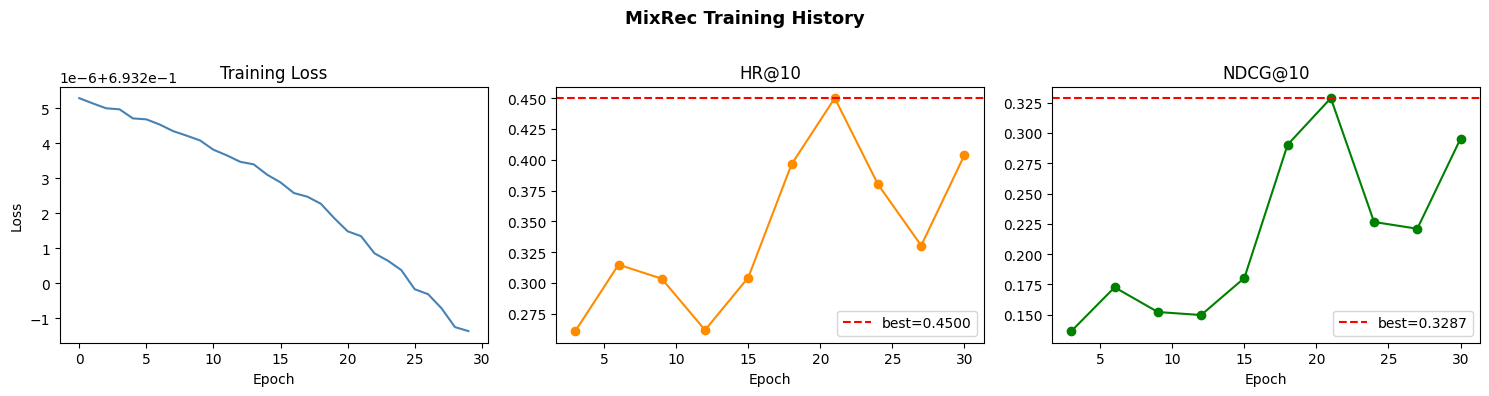

In [13]:
# Cell 13 — Training curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('MixRec Training History', fontsize=13, fontweight='bold')

axes[0].plot(history['train_loss'], color='steelblue')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(history['epoch'], history['HR@10'], color='darkorange', marker='o')
axes[1].axhline(best_hr, color='red', linestyle='--', label=f'best={best_hr:.4f}')
axes[1].set_title('HR@10')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history['epoch'], history['NDCG@10'], color='green', marker='o')
axes[2].axhline(best_ndcg, color='red', linestyle='--', label=f'best={best_ndcg:.4f}')
axes[2].set_title('NDCG@10')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=120)
plt.show()

---
## Section 6 — Hyperparameter Tuning

We sweep 3 key hyperparameters that most affect MixRec's performance:

| Parameter | What it controls | Values to try |
|---|---|---|
| `latdim` | Embedding size — richer = more expressive but slower | 16, 32, 64 |
| `lr` | Learning rate — too high = unstable, too low = slow | 1e-3, 1e-4, 1e-5 |
| `ssl_reg` | Weight of contrastive loss — higher = more behavior alignment | 1e-4, 1e-5, 1e-6 |

We use **quick eval** (5 epochs per config, 2000 test users) to find the best combination, then do a full run with the winner.

In [14]:
# Cell 14 — Hyperparameter sweep

import copy

# Define the grid
sweep_grid = {
    'latdim'  : [16, 32, 64],
    'lr'      : [1e-3, 1e-4, 1e-5],
    'ssl_reg' : [1e-4, 1e-5, 1e-6],
}

# Quick eval settings (fast but informative)
SWEEP_EPOCHS    = 5      # epochs per config
SWEEP_TST_USERS = 2000   # test users per eval

sweep_results = []

# Generate all combinations
from itertools import product as iproduct
all_configs = [
    {'latdim': ld, 'lr': lr, 'ssl_reg': sr}
    for ld, lr, sr in iproduct(
        sweep_grid['latdim'],
        sweep_grid['lr'],
        sweep_grid['ssl_reg']
    )
]
print(f'Total configurations to sweep: {len(all_configs)}')
print('Each runs for', SWEEP_EPOCHS, 'epochs.\n')

eval_sample = np.random.choice(tst_users, SWEEP_TST_USERS, replace=False).tolist()

for idx, cfg in enumerate(all_configs):
    # Build a config with overrides
    sweep_args = copy.copy(args)
    sweep_args.latdim  = cfg['latdim']
    sweep_args.lr      = cfg['lr']
    sweep_args.ssl_reg = cfg['ssl_reg']
    sweep_args.epoch   = SWEEP_EPOCHS

    torch.manual_seed(42)
    np.random.seed(42)
    sweep_model = MixRec(n_users, n_items, sweep_args).to(device)
    sweep_opt   = torch.optim.Adam(sweep_model.parameters(), lr=sweep_args.lr)

    # Train for SWEEP_EPOCHS
    for ep in range(SWEEP_EPOCHS):
        train_one_epoch(
            sweep_model, sweep_opt, trn_users, beh_mats, label_mat,
            n_users, n_items, sweep_args, device
        )

    # Quick eval
    metrics = evaluate(
        sweep_model, eval_sample, tst_buy, beh_mats, label_mat,
        n_users, n_items, sweep_args, device
    )

    result = {**cfg, 'HR@10': metrics['HR@10'], 'NDCG@10': metrics['NDCG@10']}
    sweep_results.append(result)

    print(f'[{idx+1:2d}/{len(all_configs)}] latdim={cfg["latdim"]:2d} | '
          f'lr={cfg["lr"]:.0e} | ssl_reg={cfg["ssl_reg"]:.0e} | '
          f'HR@10={metrics["HR@10"]:.4f} | NDCG@10={metrics["NDCG@10"]:.4f}')

    del sweep_model
    torch.cuda.empty_cache()

Total configurations to sweep: 27
Each runs for 5 epochs.



Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]

[ 1/27] latdim=16 | lr=1e-03 | ssl_reg=1e-04 | HR@10=0.6486 | NDCG@10=0.4820


Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]

[ 2/27] latdim=16 | lr=1e-03 | ssl_reg=1e-05 | HR@10=0.6757 | NDCG@10=0.5020


...

[25/27] latdim=64 | lr=1e-05 | ssl_reg=1e-04 | HR@10=0.1081 | NDCG@10=0.0807


Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]

[26/27] latdim=64 | lr=1e-05 | ssl_reg=1e-05 | HR@10=0.1081 | NDCG@10=0.0801


Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]

[27/27] latdim=64 | lr=1e-05 | ssl_reg=1e-06 | HR@10=0.1351 | NDCG@10=0.0891


In [15]:
# Cell 15 — Show sweep results as a sorted table
import pandas as pd

results_df = pd.DataFrame(sweep_results)
results_df = results_df.sort_values('HR@10', ascending=False)

print('=== HYPERPARAMETER SWEEP RESULTS (sorted by HR@10) ===')
print(results_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

best_cfg = results_df.iloc[0]
print(f'\n=== BEST CONFIG ===')
print(f'  latdim  = {int(best_cfg.latdim)}')
print(f'  lr      = {best_cfg.lr:.0e}')
print(f'  ssl_reg = {best_cfg.ssl_reg:.0e}')
print(f'  HR@10   = {best_cfg["HR@10"]:.4f}')
print(f'  NDCG@10 = {best_cfg["NDCG@10"]:.4f}')

=== HYPERPARAMETER SWEEP RESULTS (sorted by HR@10) ===
 latdim     lr  ssl_reg  HR@10  NDCG@10
     64 0.0010   0.0000 0.9189   0.6648
     32 0.0010   0.0000 0.8649   0.6628
     32 0.0010   0.0001 0.8378   0.5808
     32 0.0010   0.0000 0.8378   0.6610
     64 0.0010   0.0000 0.7568   0.6318
     16 0.0010   0.0000 0.7568   0.6149
     64 0.0010   0.0001 0.7027   0.6707
     16 0.0010   0.0000 0.6757   0.5020
     16 0.0010   0.0001 0.6486   0.4820
     64 0.0001   0.0000 0.5135   0.3590
     32 0.0001   0.0000 0.3784   0.2356
     64 0.0001   0.0001 0.3243   0.1976
     64 0.0001   0.0000 0.2432   0.2017
     16 0.0001   0.0000 0.1892   0.0975
     32 0.0001   0.0000 0.1622   0.1093
     32 0.0000   0.0000 0.1622   0.1010
     32 0.0000   0.0000 0.1622   0.1109
     16 0.0001   0.0000 0.1351   0.0454
     32 0.0001   0.0001 0.1351   0.0840
     32 0.0000   0.0001 0.1351   0.0896
     64 0.0000   0.0000 0.1351   0.0891
     64 0.0000   0.0001 0.1081   0.0807
     64 0.0000   0.0000 0

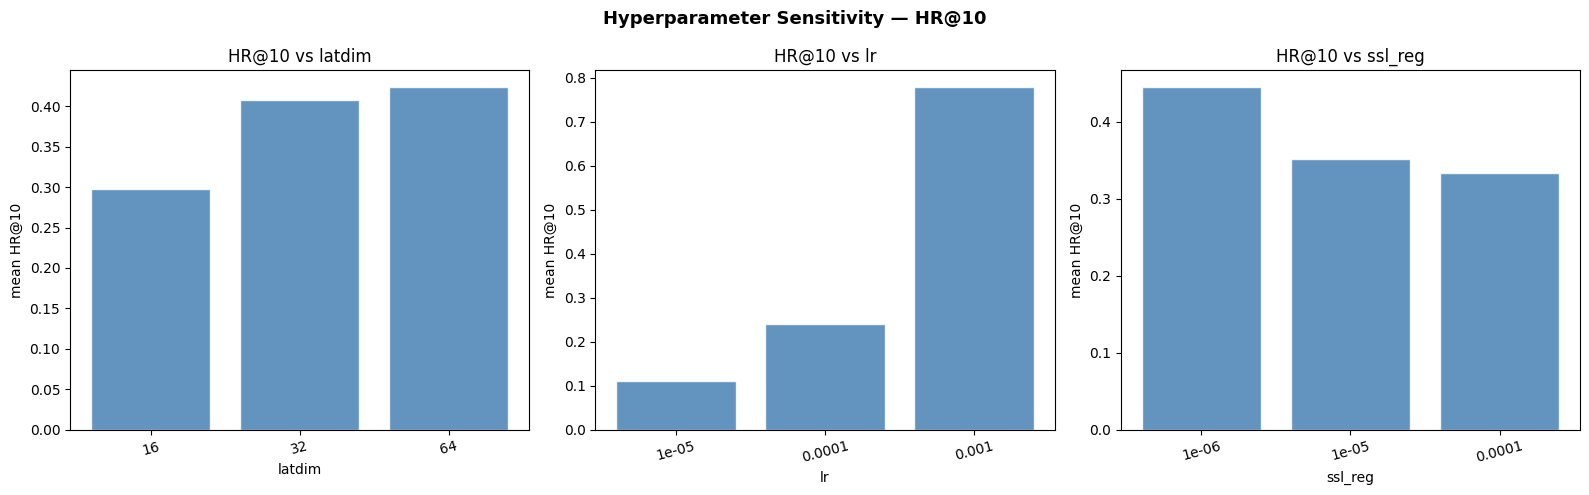

In [16]:
# Cell 16 — Visualise sweep results
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Hyperparameter Sensitivity — HR@10', fontsize=13, fontweight='bold')

for ax, param in zip(axes, ['latdim', 'lr', 'ssl_reg']):
    grouped = results_df.groupby(param)['HR@10'].mean().reset_index()
    ax.bar(range(len(grouped)), grouped['HR@10'],
           color='steelblue', alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels([str(v) for v in grouped[param]], rotation=15)
    ax.set_title(f'HR@10 vs {param}')
    ax.set_xlabel(param)
    ax.set_ylabel('mean HR@10')

plt.tight_layout()
plt.savefig('/kaggle/working/sweep_results.png', dpi=120)
plt.show()

In [17]:
# Cell 17 — Final run with best hyperparameters
# After the sweep, retrain from scratch with the best config for more epochs.

print('=== FINAL RUN WITH BEST HYPERPARAMETERS ===')

final_args = copy.copy(args)
final_args.latdim  = int(best_cfg.latdim)
final_args.lr      = best_cfg.lr
final_args.ssl_reg = best_cfg.ssl_reg
final_args.epoch   = 50   # more epochs for final run
final_args.patience = 5

print(f'Config: latdim={final_args.latdim}, lr={final_args.lr:.0e}, ssl_reg={final_args.ssl_reg:.0e}')

torch.manual_seed(42)
np.random.seed(42)

final_model = MixRec(n_users, n_items, final_args).to(device)
final_opt   = torch.optim.Adam(final_model.parameters(), lr=final_args.lr)
final_sched = torch.optim.lr_scheduler.ExponentialLR(final_opt, gamma=final_args.decay)

final_history = {'train_loss': [], 'HR@10': [], 'NDCG@10': [], 'epoch': []}
best_final_hr   = 0.0
best_final_ndcg = 0.0
patience_counter = 0

for epoch in range(1, final_args.epoch + 1):
    t0 = time.time()
    m  = train_one_epoch(
        final_model, final_opt, trn_users, beh_mats, label_mat,
        n_users, n_items, final_args, device
    )
    final_sched.step()
    final_history['train_loss'].append(m['loss'])

    if epoch % final_args.tstEpoch == 0:
        sample = np.random.choice(tst_users, min(5000, len(tst_users)), replace=False).tolist()
        ev = evaluate(final_model, sample, tst_buy, beh_mats, label_mat,
                      n_users, n_items, final_args, device)
        hr, ndcg = ev['HR@10'], ev['NDCG@10']
        final_history['HR@10'].append(hr)
        final_history['NDCG@10'].append(ndcg)
        final_history['epoch'].append(epoch)

        tag = ''
        if hr > best_final_hr:
            best_final_hr   = hr
            best_final_ndcg = ndcg
            patience_counter = 0
            tag = ' ← best'
            torch.save(final_model.state_dict(), '/kaggle/working/mixrec_final_best.pt')
        else:
            patience_counter += 1

        print(f'Epoch {epoch:3d} | loss={m["loss"]:.4f} | HR@10={hr:.4f} | NDCG@10={ndcg:.4f} | {time.time()-t0:.1f}s{tag}')

        if patience_counter >= final_args.patience:
            print(f'Early stopping.')
            break
    else:
        print(f'Epoch {epoch:3d} | loss={m["loss"]:.4f} | {time.time()-t0:.1f}s')

print(f'\n=== FINAL BEST: HR@10={best_final_hr:.4f} | NDCG@10={best_final_ndcg:.4f} ===')

=== FINAL RUN WITH BEST HYPERPARAMETERS ===
Config: latdim=64, lr=1e-03, ssl_reg=1e-06
Epoch   1 | loss=0.6932 | 5.6s
Epoch   2 | loss=0.6931 | 5.4s


Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch   3 | loss=0.6930 | HR@10=0.6696 | NDCG@10=0.4768 | 6.4s ← best
Epoch   4 | loss=0.6923 | 5.5s
Epoch   5 | loss=0.6891 | 5.6s


Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch   6 | loss=0.6791 | HR@10=0.7963 | NDCG@10=0.5879 | 6.9s ← best
Epoch   7 | loss=0.6592 | 5.8s
Epoch   8 | loss=0.6344 | 5.6s


...

Epoch  15 | loss=0.4609 | HR@10=0.7043 | NDCG@10=0.5589 | 5.6s
Epoch  16 | loss=0.4503 | 5.4s
Epoch  17 | loss=0.4330 | 5.5s


Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch  18 | loss=0.4284 | HR@10=0.7075 | NDCG@10=0.5186 | 5.6s
Epoch  19 | loss=0.4256 | 5.5s
Epoch  20 | loss=0.4048 | 5.2s


Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch  21 | loss=0.3916 | HR@10=0.7400 | NDCG@10=0.6023 | 5.6s
Early stopping.

=== FINAL BEST: HR@10=0.7963 | NDCG@10=0.5879 ===
